# Distributed statistic collection — results

Reads the output of `run_benchmark.py`, which runs two experiments into one `OUTPUT_DIR` (either or
both may be present):

- **traffic** (`summary.csv` + `<topology>/<variant>_traffic.csv`): incoming bytes to the **root**
  (root container eth0 RX) over time, per statistic strategy, across tree topologies.
- **contention** (`contention_summary.csv`): throughput of **general-purpose** passthrough queries
  delivered to the root under a capped root uplink, per strategy × bandwidth.

| Variant | Plan (leaf → root) | What reaches the root |
|---|---|---|
| **prometheus** | `source(leaf) → Prometheus sink(root)` | every raw tuple (largest) |
| **split** | `build(leaf) → StatisticStoreWriter(root)` | full per-window synopsis (medium) |
| **local** | `build + StatisticStoreWriter(leaf)` | only 4 scalar fields/window (smallest) |

The story: pushing raw data to a central Prometheus costs far more root-link bandwidth (traffic), and
under a constrained uplink that bandwidth is taken from real general-purpose queries (contention).

In [1]:
import glob
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Shared "paper" look, kept in sync with the other benchmarking notebooks.
sns.set_theme(style="whitegrid", context="paper")

# Sized for a VLDB/SIGMOD/ICDE two-column camera-ready: figures go in at ~1:1, so the sizes here are
# the sizes on the page (body text is 9-10pt).
PAPER_RC = {
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.2,
    "lines.markersize": 3,
    "pdf.fonttype": 42,  # TrueType, not Type-3: ACM/IEEE preflight rejects Type-3
    "ps.fonttype": 42,
}

# Column widths in inches: single column and full width of a two-column layout.
COL_W, FULL_W = 3.3, 7.0
BAR_WIDTH = 0.35  # narrow bars: grouped bars read as pairs, not slabs

# Two methods compared: WEAVE (our integrated edge path `local`, blue/solid) vs the SOTA
# non-integrated baseline (`prometheus`, red/dashed) — separable at a glance and in grayscale.
VARIANT_ORDER = ["prometheus", "local"]
VARIANT_LABEL = {
    "prometheus": "Centralized",
    "local": "Decentralized",
}
_palette = sns.color_palette("colorblind")
VARIANT_COLOR = {"prometheus": _palette[3], "local": _palette[0]}  # red (SOTA), blue (WEAVE)
VARIANT_STYLE = {"prometheus": ("--", "s"), "local": ("-", "o")}

# Same colours/labels keyed by the display label, for seaborn hue= columns.
LABEL_ORDER = [VARIANT_LABEL[v] for v in VARIANT_ORDER]
LABEL_COLOR = {VARIANT_LABEL[v]: VARIANT_COLOR[v] for v in VARIANT_ORDER}


def fmt_si(v):
    """Bar label: 15.9M / 1.6K / 4.7 — K/M/B suffixes with one decimal, never e-notation."""
    for div, suffix in ((1e9, "B"), (1e6, "M"), (1e3, "K")):
        if abs(v) >= div:
            return f"{v / div:.1f}{suffix}"
    return f"{v:.1f}" if abs(v) >= 1 else f"{v:.2g}"


In [2]:
### Point BENCHMARK_RUN at a results directory (containing summary.csv and/or contention_summary.csv),
### or leave None to auto-pick the most recent benchmark_run_dsc_* / dsc_* run under the repo root or /tmp.
BENCHMARK_RUN = None

### Rolling-window smoothing (samples) for the time series. The sampler emits ~1/s, so a small window
### just damps per-window-close burstiness without hiding the trend. Set to 1 to disable.
SMOOTH_WINDOW = 3

FIGURES = {}


def _has_results(d):
    return os.path.exists(os.path.join(d, "summary.csv")) or os.path.exists(os.path.join(d, "contention_summary.csv"))


def _autopick_run():
    here = os.getcwd()
    if _has_results(here):
        return here
    repo_root = os.path.abspath(os.path.join(here, "..", "..", "..", ".."))
    candidates = []
    for base in (repo_root, "/tmp"):
        for pat in ("benchmark_run_dsc_*", "dsc_*"):
            candidates += glob.glob(os.path.join(base, pat))
    candidates = [c for c in candidates if _has_results(c)]
    if not candidates:
        raise FileNotFoundError("No summary.csv / contention_summary.csv found; set BENCHMARK_RUN explicitly.")
    return max(candidates, key=os.path.getmtime)


if BENCHMARK_RUN is None:
    BENCHMARK_RUN = _autopick_run()
print("Using results from:", os.path.abspath(BENCHMARK_RUN))
print("  traffic    (summary.csv):           ", os.path.exists(os.path.join(BENCHMARK_RUN, "summary.csv")))
print("  contention (contention_summary.csv):", os.path.exists(os.path.join(BENCHMARK_RUN, "contention_summary.csv")))

Using results from: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/distributed_statistic_collection/plots
  traffic    (summary.csv):            True
  contention (contention_summary.csv): True


# Traffic — incoming bytes to the root

Rendered only if `summary.csv` is present (the `traffic` mode ran).

In [3]:
def _topo_dir(topology):
    return topology.replace("/", "-")


def load_traffic(topology, variant):
    path = os.path.join(BENCHMARK_RUN, _topo_dir(topology), f"{variant}_traffic.csv")
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    df["topology"] = topology
    df["variant"] = variant
    df["variant_label"] = VARIANT_LABEL[variant]
    df["root_rx_mbps"] = df["root_rx_bps"] / 1e6
    df["root_rx_mbps_smooth"] = (
        df["root_rx_mbps"].rolling(SMOOTH_WINDOW, min_periods=1, center=True).mean()
        if SMOOTH_WINDOW > 1
        else df["root_rx_mbps"]
    )
    return df


_summary_path = os.path.join(BENCHMARK_RUN, "summary.csv")
if os.path.exists(_summary_path):
    summary = pd.read_csv(_summary_path)
    summary["total_mb"] = summary["total_bytes"] / 1e6
    summary["variant_label"] = summary["variant"].map(VARIANT_LABEL)
    TOPOLOGIES = list(dict.fromkeys(summary["topology"]))
    _parts = [load_traffic(t, v) for t in TOPOLOGIES for v in VARIANT_ORDER]
    _parts = [p for p in _parts if p is not None]
    ts = pd.concat(_parts, ignore_index=True) if _parts else None
else:
    summary, ts, TOPOLOGIES = None, None, []
    print("no summary.csv (traffic mode not run) — traffic cells will skip.")
summary

,topology,variant,total_bytes,peak_bps,num_queries,num_leaves,total_mb,variant_label
0,1/2,prometheus,493147924,16690923.4,8,2,493.147924,Centralized
1,1/2,split,4066288,164107.6,8,2,4.066288,NaN
2,1/2,local,174945,33098.3,8,2,0.174945,Decentralized


## Total incoming traffic to the root, per topology

Grouped bars (log scale): for each topology, how much each strategy sends to the root over the run.

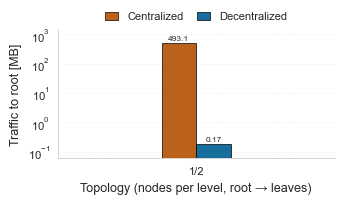

In [4]:
if summary is None:
    print("skipped (no traffic results)")
else:
    shown = summary[summary["variant"].isin(VARIANT_ORDER)]
    with sns.plotting_context("paper", rc=PAPER_RC):
        fig, ax = plt.subplots(figsize=(COL_W, 1.9))
        sns.barplot(
            data=shown,
            x="topology",
            y="total_mb",
            order=TOPOLOGIES,
            hue="variant_label",
            hue_order=LABEL_ORDER,
            palette=LABEL_COLOR,
            width=BAR_WIDTH,
            edgecolor="black",
            linewidth=0.5,
            ax=ax,
        )
        ax.set_yscale("log")
        ax.set_xlabel("Topology (nodes per level, root → leaves)")
        ax.set_ylabel("Traffic to root [MB]")
        ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6)
        ax.tick_params(length=2, width=0.6)
        sns.despine(ax=ax)
        # Value on top of every bar.
        for container in ax.containers:
            ax.bar_label(container, labels=[fmt_si(b.get_height()) for b in container], padding=1.5, fontsize=6)
        # Pad the categorical axis so a run with few topologies doesn't stretch its bars into slabs;
        # bar width is fixed in data units, so the padding is what keeps them thin.
        ax.set_xlim(-0.7, len(TOPOLOGIES) - 0.3)
        # Log axis: bars grow from the bottom spine, so give the shortest plotted bar room to be visible.
        # Headroom on top so the value labels aren't clipped.
        ax.set_ylim(bottom=shown["total_mb"].min() / 3, top=ax.get_ylim()[1] * 2)
        # Legend above the axes (single row, no frame) — no suptitle, the caption carries it.
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()
        ax.legend(
            handles,
            labels,
            loc="lower center",
            bbox_to_anchor=(0.5, 1.0),
            ncol=len(labels),
            frameon=False,
            handlelength=1.2,
            columnspacing=1.2,
            borderpad=0.2,
        )
        fig.tight_layout(pad=0.2)
        FIGURES["total_root_rx_by_topology"] = fig
        plt.show()


## Incoming traffic to the root over time

One panel per topology, one line per variant (log y-axis).

In [5]:
if ts is None:
    print("skipped (no traffic time series)")
else:
    with sns.plotting_context("paper", rc=PAPER_RC):
        # Solid/dashed + markers per variant so the lines stay separable in grayscale prints,
        # matching VARIANT_STYLE. seaborn wants dash tuples (empty == solid) rather than "-"/"--".
        _DASH_FOR = {"--": (4, 2), "-.": (4, 1.5, 1, 1.5), "-": ""}
        LABEL_DASH = {VARIANT_LABEL[v]: _DASH_FOR[VARIANT_STYLE[v][0]] for v in VARIANT_ORDER}
        LABEL_MARKER = {VARIANT_LABEL[v]: VARIANT_STYLE[v][1] for v in VARIANT_ORDER}
        g = sns.relplot(
            data=ts,
            x="elapsed_s",
            y="root_rx_mbps_smooth",
            col="topology",
            col_order=TOPOLOGIES,
            col_wrap=min(2, len(TOPOLOGIES)),
            hue="variant_label",
            hue_order=LABEL_ORDER,
            palette=LABEL_COLOR,
            style="variant_label",
            style_order=LABEL_ORDER,
            dashes=LABEL_DASH,
            markers=LABEL_MARKER,
            kind="line",
            height=3.0,
            aspect=1.3,
            facet_kws={"sharey": True, "sharex": False},
        )
        g.set(yscale="log")
        g.set_axis_labels("Time (s)", "Incoming traffic to root (MB/s)")
        g.set_titles("topology = {col_name}")
        for ax in g.axes.flat:
            ax.grid(True, axis="both", linestyle=":", linewidth=0.5, alpha=0.6)
            sns.despine(ax=ax)
        if g.legend is not None:
            g.legend.set_title(None)
        g.figure.subplots_adjust(top=0.88)
        g.figure.suptitle("Incoming traffic to root over time", y=1.02)
        FIGURES["root_rx_over_time"] = g.figure
        plt.show()

skipped (no traffic time series)


# Contention — general-purpose query throughput under a capped root uplink

Rendered only if `contention_summary.csv` is present (the `contention` mode ran). GP passthrough
queries stream to the root alongside the statistic workload while the root's incoming bandwidth is
capped (caps set in **kbit** via `BANDWIDTH_LIMITS_KBIT`; `0` = uncapped baseline). The bars show GP
throughput *delivered to the root*: with **SOTA/Non-Integrated** the raw statistic stream saturates the
shared link and starves the GP queries, while **WEAVE** leaves the link free so GP throughput stays high.

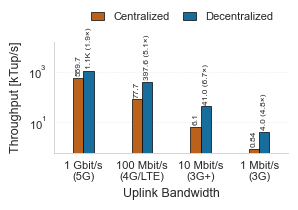

topology    variant  bandwidth_kbit  gp_throughput_tps  gp_num_queries  num_leaves variant_label  gp_throughput_ktps             bw_label
     1/2      local            1000             3991.6               2           2 Decentralized              3.9916       1 Mbit/s\n(3G)
     1/2      local           10000            40961.2               2           2 Decentralized             40.9612     10 Mbit/s\n(3G+)
     1/2      local          100000           397621.0               2           2 Decentralized            397.6210 100 Mbit/s\n(4G/LTE)
     1/2      local         1000000          1067910.5               2           2 Decentralized           1067.9105       1 Gbit/s\n(5G)
     1/2 prometheus            1000              837.8               2           2   Centralized              0.8378       1 Mbit/s\n(3G)
     1/2 prometheus           10000             6149.1               2           2   Centralized              6.1491     10 Mbit/s\n(3G+)
     1/2 prometheus          10000

In [6]:
contention_path = os.path.join(BENCHMARK_RUN, "contention_summary.csv")
if not os.path.exists(contention_path):
    print("skipped (no contention_summary.csv)")
else:
    cdf = pd.read_csv(contention_path)
    # Drop the uncapped baseline (0): it isn't link-bound, so it has no meaningful speedup to show.
    # All capped points (down to 1 Mbit/s / 3G) are kept.
    cdf = cdf[~cdf["bandwidth_kbit"].isin([0])].copy()
    cdf["variant_label"] = cdf["variant"].map(VARIANT_LABEL)
    cdf["gp_throughput_ktps"] = cdf["gp_throughput_tps"] / 1e3

    # Cellular generation each cap roughly stands in for on the edge->cloud uplink, shown under the rate.
    # 1 Gbit/s ~ 5G, 100 Mbit/s ~ 4G/LTE, 10 Mbit/s ~ HSPA+ (3G+), 1 Mbit/s ~ HSPA (3G).
    GENERATION = {1_000_000: "5G", 100_000: "4G/LTE", 10_000: "3G+", 1_000: "3G"}

    def _bw_label(k):
        # Two-line tick: bit-rate in its highest natural unit ("1 Gbit/s") over the cellular generation it maps to.
        if k == 0:
            return "uncapped"
        if k >= 1_000_000:
            rate = f"{k / 1_000_000:g} Gbit/s"
        elif k >= 1_000:
            rate = f"{k / 1_000:g} Mbit/s"
        else:
            rate = f"{k} kbit/s"
        gen = GENERATION.get(k)
        return f"{rate}\n({gen})" if gen else rate

    cdf["bw_label"] = cdf["bandwidth_kbit"].map(_bw_label)
    # x order: decreasing bandwidth (tighter link to the right).
    bws = sorted(cdf["bandwidth_kbit"].unique(), key=lambda k: (k != 0, -k))
    bw_order = [_bw_label(k) for k in bws]
    ctopos = list(dict.fromkeys(cdf["topology"]))

    # SOTA/Non-Integrated throughput per (topology, bandwidth) is the speedup baseline for the bar labels.
    base = cdf[cdf["variant"] == "prometheus"].set_index(["topology", "bw_label"])["gp_throughput_ktps"]

    with sns.plotting_context("paper", rc=PAPER_RC):
        g = sns.catplot(
            data=cdf,
            kind="bar",
            x="bw_label",
            order=bw_order,
            y="gp_throughput_ktps",
            hue="variant_label",
            hue_order=LABEL_ORDER,
            palette=LABEL_COLOR,
            width=BAR_WIDTH,
            edgecolor="black",
            linewidth=0.5,
            col="topology",
            col_order=ctopos,
            col_wrap=min(2, len(ctopos)),
            height=2.0,
            aspect=COL_W / 2.0,
        )
        g.set(yscale="log")
        g.set_axis_labels("Uplink Bandwidth", "Throughput [kTup/s]")
        g.set_titles("")
        for topo, ax in g.axes_dict.items():
            ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6)
            ax.tick_params(length=2, width=0.6)
            sns.despine(ax=ax)
            # One container per variant (hue), in VARIANT_ORDER; bars in bw_order. Every bar gets its
            # value; non-baseline bars also carry the speedup over the SOTA/Non-Integrated bar at the
            # same bandwidth. Rotated so the paired labels don't collide.
            for variant, container in zip(VARIANT_ORDER, ax.containers):
                labels = []
                for bw, bar in zip(bw_order, container):
                    value = fmt_si(bar.get_height())
                    ref = base.get((topo, bw), float("nan"))
                    if variant == "prometheus" or not ref:
                        labels.append(value)
                    else:
                        labels.append(f"{value} ({bar.get_height() / ref:.1f}×)")
                ax.bar_label(container, labels=labels, padding=1.5, fontsize=6, rotation=90)
            # Headroom above the tallest bar so the rotated labels don't clip on the log axis.
            ax.set_ylim(top=ax.get_ylim()[1] * 10)
        # Legend above the axes (single row, no frame) — no suptitle, the caption carries it.
        sns.move_legend(
            g,
            "lower center",
            bbox_to_anchor=(0.5, 0.94),
            ncol=len(LABEL_ORDER),
            frameon=False,
            title=None,
            handlelength=1.2,
            columnspacing=1.2,
            borderpad=0.2,
        )
        g.figure.subplots_adjust(top=0.88)
        FIGURES["gp_throughput_vs_bandwidth"] = g.figure
        plt.show()
    print(cdf.sort_values(["topology", "variant", "bandwidth_kbit"]).to_string(index=False))


## GP goodput in bytes/s under a capped root uplink

Same as above, but the y-axis is delivered **bytes/s** instead of tuples/s: `gp_throughput_tps × GP_TUPLE_BYTES`.
The GP query projects `id, value, timestamp` — three `UINT64`s (see `render_gp_query` in `run_benchmark.py`),
so every delivered tuple is 24 bytes. Speedups over Prometheus are identical to the tuples/s plot (constant factor).

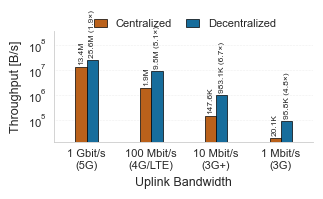

In [7]:
if not os.path.exists(contention_path):
    print("skipped (no contention_summary.csv)")
else:
    # The GP query projects id, value, timestamp — three UINT64s (render_gp_query in run_benchmark.py),
    # so every delivered tuple is 24 bytes. Turn delivered tuples/s into delivered bytes/s.
    GP_TUPLE_BYTES = 24
    cdf["gp_throughput_Bps"] = cdf["gp_throughput_tps"] * GP_TUPLE_BYTES
    base_b = cdf[cdf["variant"] == "prometheus"].set_index(["topology", "bw_label"])["gp_throughput_Bps"]

    with sns.plotting_context("paper", rc=PAPER_RC):
        g = sns.catplot(
            data=cdf,
            kind="bar",
            x="bw_label",
            order=bw_order,
            y="gp_throughput_Bps",
            hue="variant_label",
            hue_order=LABEL_ORDER,
            palette=LABEL_COLOR,
            width=BAR_WIDTH,
            edgecolor="black",
            linewidth=0.5,
            col="topology",
            col_order=ctopos,
            col_wrap=min(2, len(ctopos)),
            height=2.0,
            aspect=COL_W / 2.0,
        )
        g.set(yscale="log")
        g.set_axis_labels("Uplink Bandwidth", "Throughput [B/s]")
        g.set_titles("")
        for topo, ax in g.axes_dict.items():
            ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6)
            ax.tick_params(length=2, width=0.6)
            sns.despine(ax=ax)
            # One container per variant (hue), in VARIANT_ORDER; bars in bw_order. Every bar gets its
            # value; non-baseline bars also carry the speedup over the SOTA/Non-Integrated bar at the
            # same bandwidth. Rotated so the paired labels don't collide.
            for variant, container in zip(VARIANT_ORDER, ax.containers):
                labels = []
                for bw, bar in zip(bw_order, container):
                    value = fmt_si(bar.get_height())
                    ref = base_b.get((topo, bw), float("nan"))
                    if variant == "prometheus" or not ref:
                        labels.append(value)
                    else:
                        labels.append(f"{value} ({bar.get_height() / ref:.1f}×)")
                ax.bar_label(container, labels=labels, padding=1.5, fontsize=6, rotation=90)
            # Headroom above the tallest bar so the rotated labels don't clip on the log axis.
            ax.set_ylim(top=ax.get_ylim()[1] * 10)
        # Legend above the axes (single row, no frame) — no suptitle, the caption carries it.
        sns.move_legend(
            g,
            "lower center",
            bbox_to_anchor=(0.45, 0.85),
            ncol=len(LABEL_ORDER),
            frameon=False,
            title=None,
            handlelength=1.2,
            columnspacing=1.2,
            borderpad=0.2,
        )
        g.figure.subplots_adjust(top=0.88)
        FIGURES["gp_goodput_vs_bandwidth"] = g.figure
        plt.show()


# Save figures

Writes every figure produced above as both `.png` (300 dpi) and `.pdf` (vector) into
`<BENCHMARK_RUN>/figures/`.

In [8]:
SAVE_DIR = os.path.join(BENCHMARK_RUN, "figures")
os.makedirs(SAVE_DIR, exist_ok=True)
if not FIGURES:
    print("no figures produced (no results found).")
for name, fig in FIGURES.items():
    for ext, kwargs in [("png", {"dpi": 300}), ("pdf", {})]:
        path = os.path.join(SAVE_DIR, f"{name}.{ext}")
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print("saved:", os.path.abspath(path))

saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/distributed_statistic_collection/plots/figures/total_root_rx_by_topology.png
saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/distributed_statistic_collection/plots/figures/total_root_rx_by_topology.pdf
saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/distributed_statistic_collection/plots/figures/gp_throughput_vs_bandwidth.png
saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/distributed_statistic_collection/plots/figures/gp_throughput_vs_bandwidth.pdf
saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/distributed_statistic_collection/plots/figures/gp_goodput_vs_bandwidth.png
saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/distributed_statistic_collection/plots/figures/gp_goodput